# DNN: Ex 1 group 8

### Esteban Càrdenas ID: 2183905
### Libero Pollini ID: 2206131
### Matteo Modolo ID:2200984
### Niccolò De Poli  ID:2197920

In [1]:
! pip install tensorflow



error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.13/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [1]:
!pip install keras-tuner -q --break-system-packages

In [2]:
!pip install tensorflow --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [5]:
!pip install keras-tuner -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.13/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import layers
import keras_tuner

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

## Read data

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


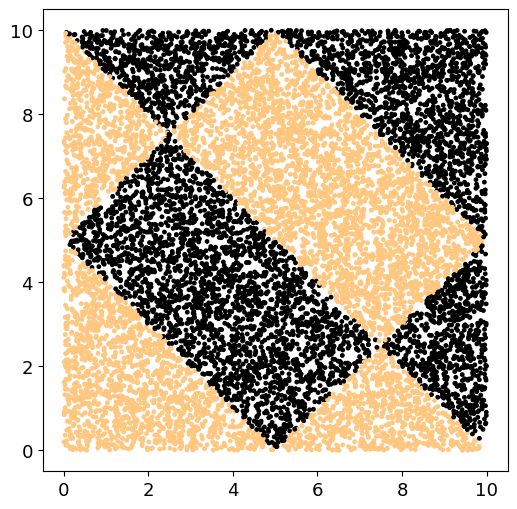

In [16]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

## Split data and standardize (fit on train only)

In [17]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


## Define the model with Keras / Tensorflow

In [18]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

# We use case 1
CASE=1

if CASE==1:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))                     #probability to lose a neuron and his connections during an iteration to add noise
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
# as case 1 but one layer shorter
if CASE==2:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(40,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
#deeper
if CASE==3:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
    
print(model.summary())
#number of total parameters should be lower of size of training

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

None


## Optimization method and cost function

In [19]:
model.compile(loss='binary_crossentropy', #loss function
              optimizer='RMSprop',        
              #optimizer='adam',
              metrics=['accuracy'])

## Training

In [20]:
fit = model.fit(x_train, y_train,
               epochs = nepoch, batch_size = 50, #size of dataset where im doing the gradient
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
168/168 - 2s - 9ms/step - accuracy: 0.5233 - loss: 0.6910 - val_accuracy: 0.5400 - val_loss: 0.6880
Epoch 2/200
168/168 - 0s - 2ms/step - accuracy: 0.5314 - loss: 0.6890 - val_accuracy: 0.5422 - val_loss: 0.6861
Epoch 3/200
168/168 - 0s - 2ms/step - accuracy: 0.5436 - loss: 0.6836 - val_accuracy: 0.5311 - val_loss: 0.6824
Epoch 4/200
168/168 - 0s - 1ms/step - accuracy: 0.5314 - loss: 0.6803 - val_accuracy: 0.5294 - val_loss: 0.6745
Epoch 5/200
168/168 - 0s - 1ms/step - accuracy: 0.5451 - loss: 0.6719 - val_accuracy: 0.5500 - val_loss: 0.6605
Epoch 6/200
168/168 - 0s - 1ms/step - accuracy: 0.5601 - loss: 0.6567 - val_accuracy: 0.5844 - val_loss: 0.6410
Epoch 7/200
168/168 - 0s - 1ms/step - accuracy: 0.5817 - loss: 0.6381 - val_accuracy: 0.6000 - val_loss: 0.6193
Epoch 8/200
168/168 - 0s - 1ms/step - accuracy: 0.5993 - loss: 0.6165 - val_accuracy: 0.6311 - val_loss: 0.5907
Epoch 9/200
168/168 - 0s - 1ms/step - accuracy: 0.6549 - loss: 0.5904 - val_accuracy: 0.7328 - val_loss:

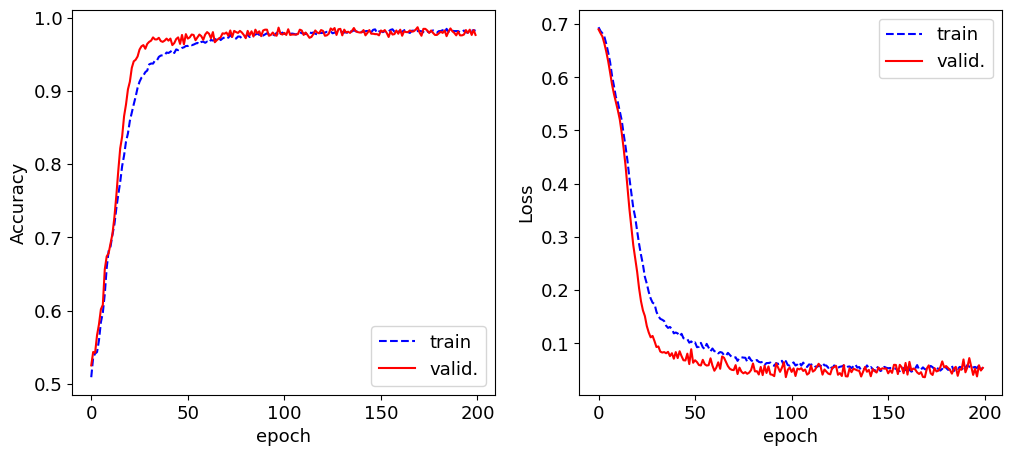

In [8]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

# Evaluation on the test set


In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.0702
Final test accuracy: 0.9728


## Grid to show preditions

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


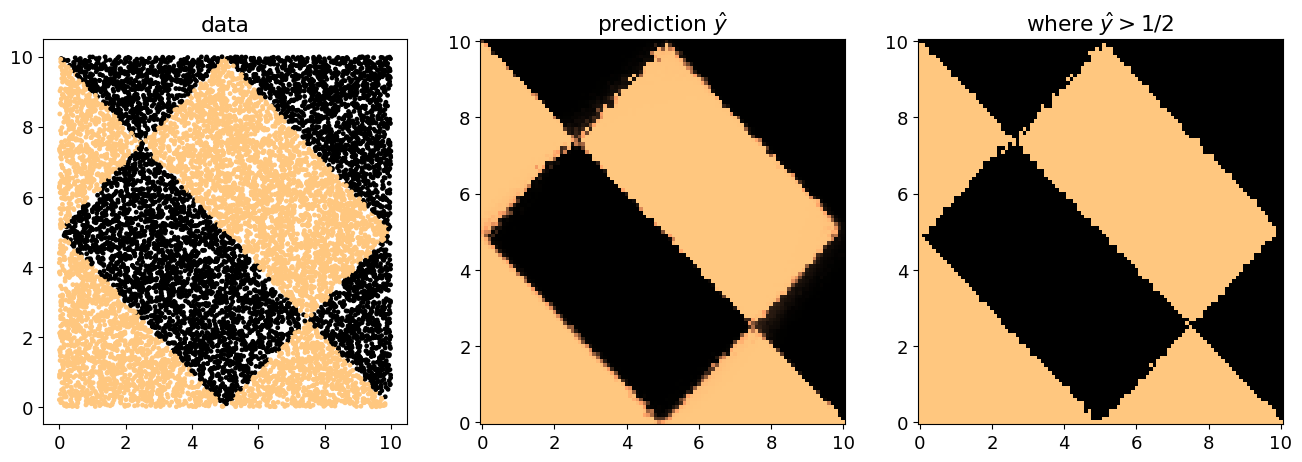

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [10]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

In [23]:
import sys
!{sys.executable} -m pip install tensorboard --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached markdown-3.10.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-manylinux_2_31_x86_64.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.6-py3-none-any.whl.metadata (4.0 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-manylinux_2_31_x86_64.whl (6.6 MB)
Using cached markdown-3.10.2-py3-none-any.whl (108 kB)
Using cached werkzeug-3.1.6-py3-none-any.whl (225 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [tensorboard] 3/4 [tensorboard]data-server]


## 1


In [22]:
import keras
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.model_selection import KFold
#define search options
def build_model(hp):
    model = keras.Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(20,activation=hp.Choice("activation",["relu","sigmoid","elu","leaky_relu"])))
    model.add(Dropout(hp.Choice("dropout",[0.0,0.1,0.2])))
    model.add(Dense(20,activation=hp.Choice("activation",["relu","sigmoid","elu","leaky_relu"])))
    model.add(Dropout(hp.Choice("dropout",[0.0,0.1,0.2])))
    model.add(Dense(20,activation=hp.Choice("activation",["relu","sigmoid","elu","leaky_relu"])))
    model.add(Dropout(hp.Choice("dropout",[0.0,0.1,0.2])))
    model.add(Dense(1,activation="sigmoid"))
    nepoch=200
    lr = hp.Choice("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
    optimizer_name = hp.Choice("optimizer", ["adam", "rmsprop", "nesterov"])
    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = RMSprop(learning_rate=lr)
    else:
        optimizer = SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model
build_model(keras_tuner.HyperParameters())
#setting tuner parameters          
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=2,
    overwrite=True,
    directory="my_dir",
    project_name="NNTuning"
)
tuner.search_space_summary()
tuner.search(x_train, y_train, epochs=100, validation_data=(x_valid, y_valid)) #running search among options
#k fold between best found models
best_hyperparams = tuner.get_best_hyperparameters(num_trials=3)
kf = KFold(n_splits=5, shuffle=True)
best_score=0
best_hyper=-1
model_scores=[]

for hp in best_hyperparams:
    model_perf=0
    for train_index, val_index in kf.split(x_train):
        model = build_model(hp)
        model.fit(x_train[train_index], y_train[train_index], epochs=100, verbose=0)
        score = model.evaluate(x_train[val_index], y_train[val_index], verbose=0)
        model_perf+=score[1]/5
    model_scores.append(model_perf)
    if(model_perf>best_score):
        best_score=model_perf
        best_hyper=hp
print("Best Hyperparameters", best_hyper.values)
print("Accuracy of the best", best_score)
print("Performance", model_scores)

best_act = best_hyper.get("activation")
best_drop=best_hyper.get("dropout")
best_lr=best_hyper.get("lr")
best_opt=best_hyper.get("optimizer")

Trial 10 Complete [00h 01m 11s]
val_accuracy: 0.5533333420753479

Best val_accuracy So Far: 0.9811111092567444
Total elapsed time: 00h 12m 15s
Best Hyperparameters {'activation': 'elu', 'dropout': 0.1, 'lr': 0.001, 'optimizer': 'rmsprop'}
Accuracy of the best 0.9809523820877076
Performance [0.9809523820877076, 0.960357141494751, 0.9609523773193359]


#### We ran the code multiple times and we notice that:
#### In general sigmoid is not choosen
#### No big differences are noted for the other hyperparameters

## 2.a

 Train Acc=0.9776, Test Acc=0.9733


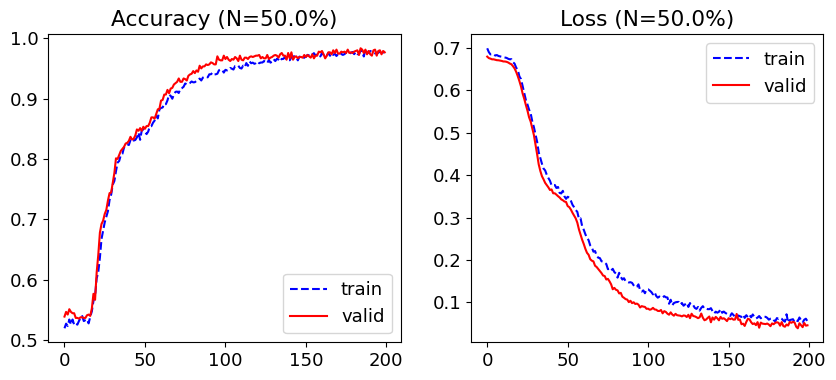

 Train Acc=0.9817, Test Acc=0.9741


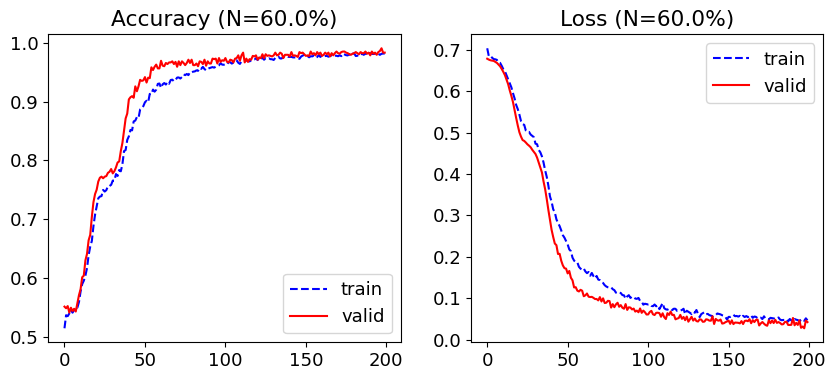

 Train Acc=0.9862, Test Acc=0.9833


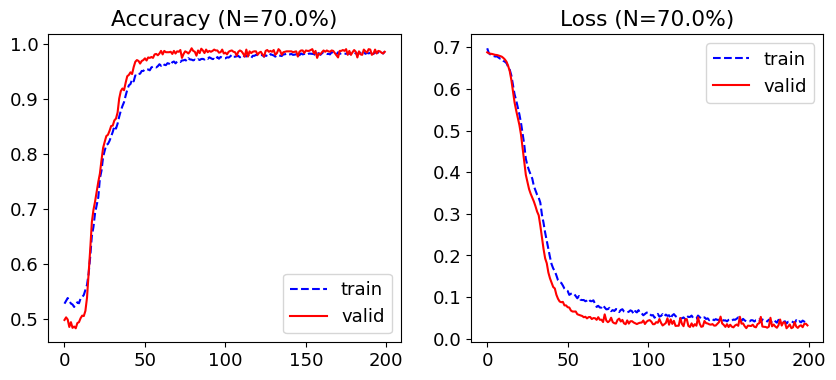

 Train Acc=0.9717, Test Acc=0.9736


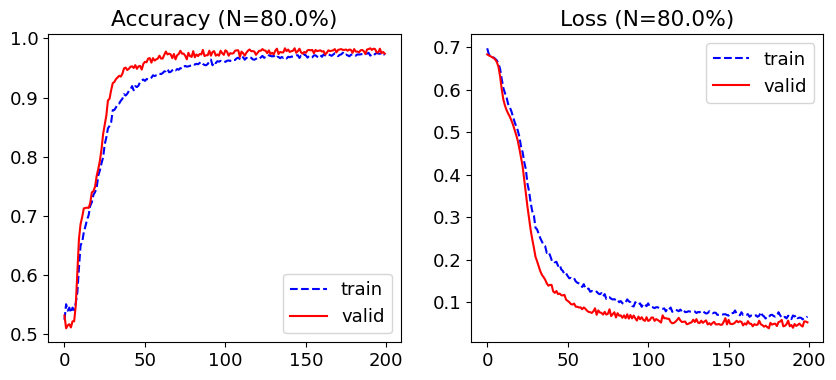

 Train Acc=0.9815, Test Acc=0.9864


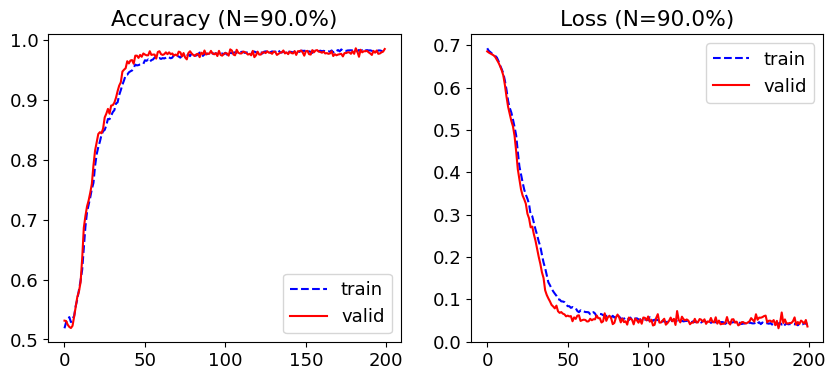

 Train Acc=0.9815, Test Acc=0.9883


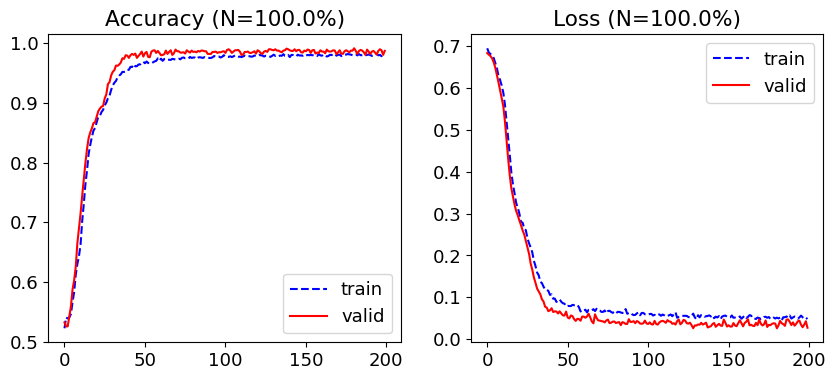

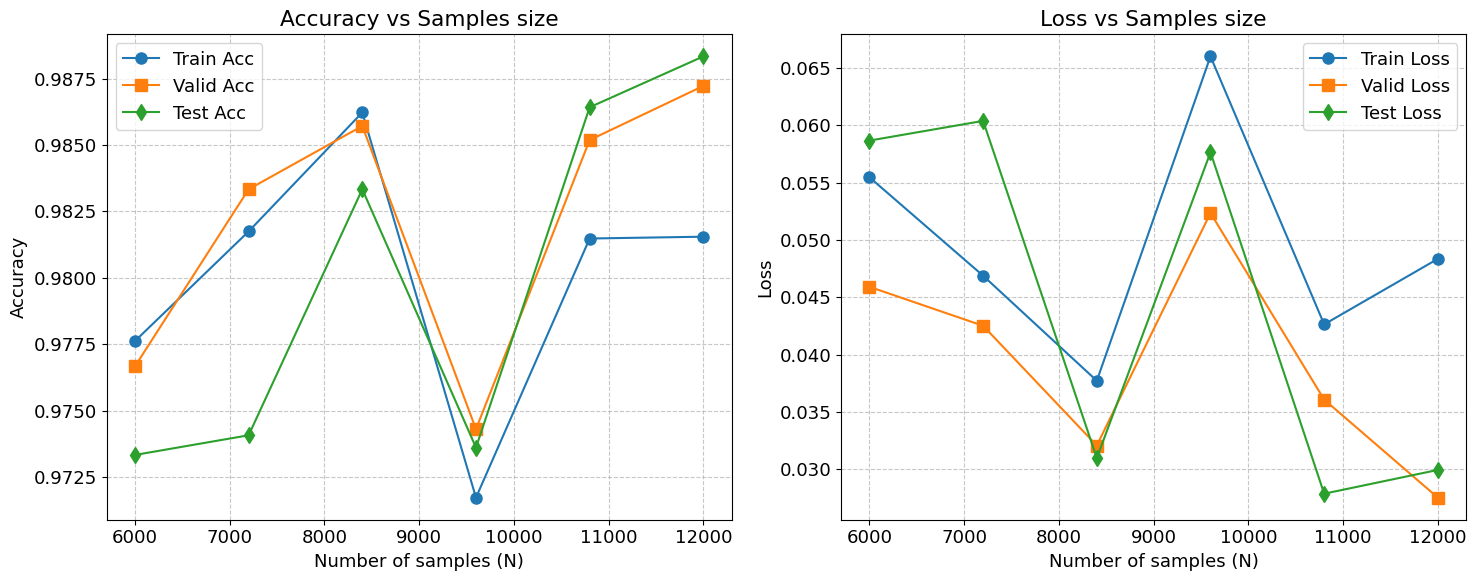

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow.random as tf_r

reduction = [0.5, 0.6, 0.7, 0.8, 0.9, 1]
N_subsets = [int(len(x) * r) for r in reduction]

train_acc_final, train_loss_final = [], []
valid_acc_final, valid_loss_final = [], []
test_acc_V, test_loss_V = [], []


np.random.seed(12345)



for n in N_subsets:
    
    N_train = int(perc_train * n)
    N_valid = int(perc_valid * n)
    N_test  = int(perc_test * n)

    x_train, y_train = x[0:N_train], y[0:N_train]
    x_valid, y_valid = x[N_train : N_train+N_valid], y[N_train : N_train+N_valid]
    x_test,  y_test  = x[N_train+N_valid : N_train+N_valid+N_test], y[N_train+N_valid : N_train+N_valid+N_test]

    x_train_mean = np.mean(x_train, axis=0)
    x_train_std  = np.std(x_train, axis=0)

    x_train = Standardize(x_train, x_train_mean, x_train_std)
    x_valid = Standardize(x_valid, x_train_mean, x_train_std)
    x_test  = Standardize(x_test,  x_train_mean, x_train_std)
#NN with best hyperparameters
    tf_r.set_seed(12345) 
    model = Sequential([
        Dense(L, input_shape=(L,), activation='relu'),
        Dense(20, activation=best_act),
        Dropout(best_drop),
        Dense(20, activation=best_act),
        Dropout(best_drop),
        Dense(20, activation=best_act),
        Dropout(best_drop),
        Dense(1, activation='sigmoid')
    ])
    if best_opt == "adam":
        opt = Adam(learning_rate=best_lr) 
    elif best_opt == "rmsprop": 
        opt = RMSprop(learning_rate=best_lr, rho=0.9)

    elif best_opt == "nesterov": 
        opt = SGD(learning_rate=best_lr, momentum=0.9, nesterov=True)

    else:
        opt = "adam"

        
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    
    
    nepoch = 200
    fit = model.fit(x_train, y_train,
                    epochs=nepoch, 
                    batch_size=50,
                    validation_data=(x_valid, y_valid),
                    verbose=0) 

    
    train_acc_final.append(fit.history['accuracy'][-1])
    train_loss_final.append(fit.history['loss'][-1])
    valid_acc_final.append(fit.history['val_accuracy'][-1])
    valid_loss_final.append(fit.history['val_loss'][-1])

    
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    test_loss_V.append(test_loss)
    test_acc_V.append(test_acc)
    
    print(f" Train Acc={train_acc_final[-1]:.4f}, Test Acc={test_acc:.4f}")

    
    fig, AX = plt.subplots(1, 2, figsize=(10, 4))
    AX[0].plot(fit.history['accuracy'], label="train", ls="--", c="b")
    AX[0].plot(fit.history['val_accuracy'], label="valid", c="r")
    AX[0].set_title(f"Accuracy (N={n/N*100}%)")
    AX[0].legend()
    AX[1].plot(fit.history['loss'], label="train", ls="--", c="b")
    AX[1].plot(fit.history['val_loss'], label="valid", c="r")
    AX[1].set_title(f"Loss (N={n/N*100}%)")
    AX[1].legend()
    plt.show()

#performaces plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(N_subsets, train_acc_final, 'o-', label='Train Acc', markersize=8)
ax1.plot(N_subsets, valid_acc_final, 's-', label='Valid Acc', markersize=8)
ax1.plot(N_subsets, test_acc_V, 'd-', label='Test Acc', markersize=8)
ax1.set_xlabel('Number of samples (N)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Samples size')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

ax2.plot(N_subsets, train_loss_final, 'o-', label='Train Loss', markersize=8)
ax2.plot(N_subsets, valid_loss_final, 's-', label='Valid Loss', markersize=8)
ax2.plot(N_subsets, test_loss_V, 'd-', label='Test Loss', markersize=8)
ax2.set_xlabel('Number of samples (N)')
ax2.set_ylabel('Loss')
ax2.set_title('Loss vs Samples size')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

## 2.b

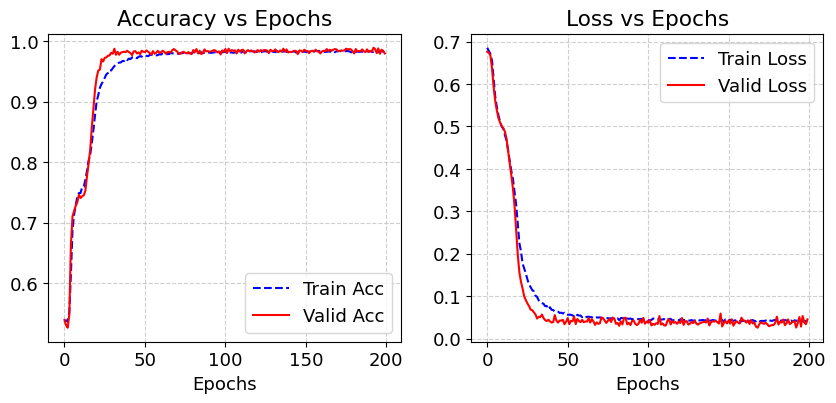

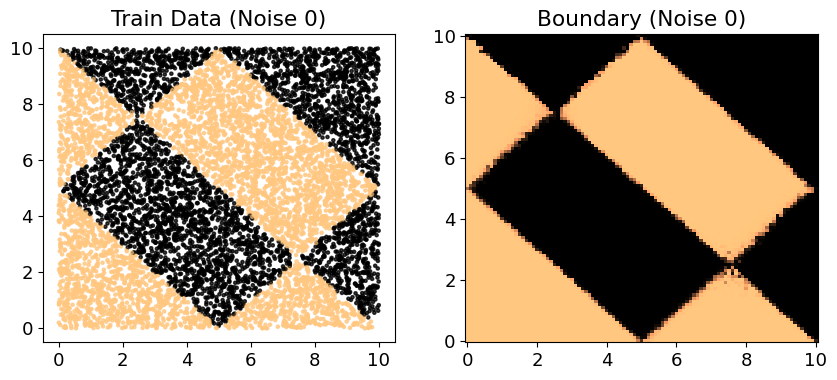

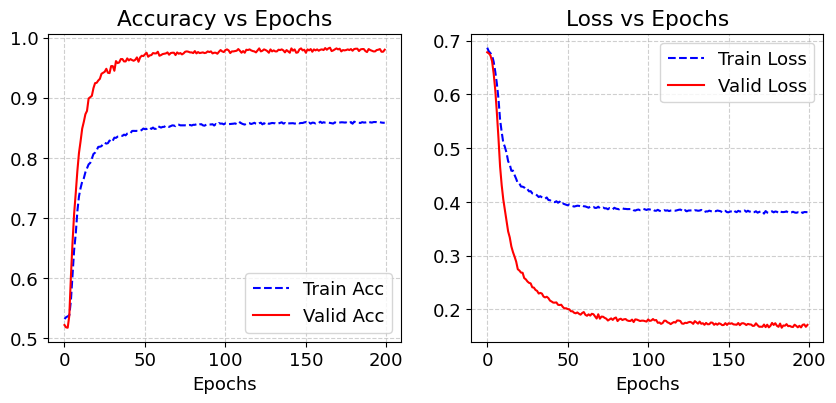

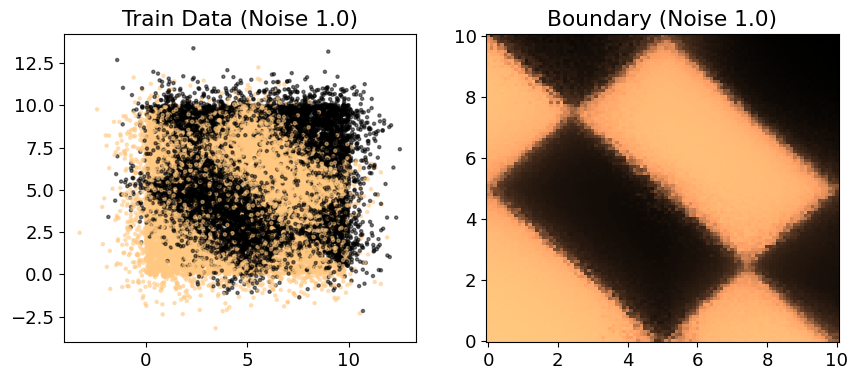

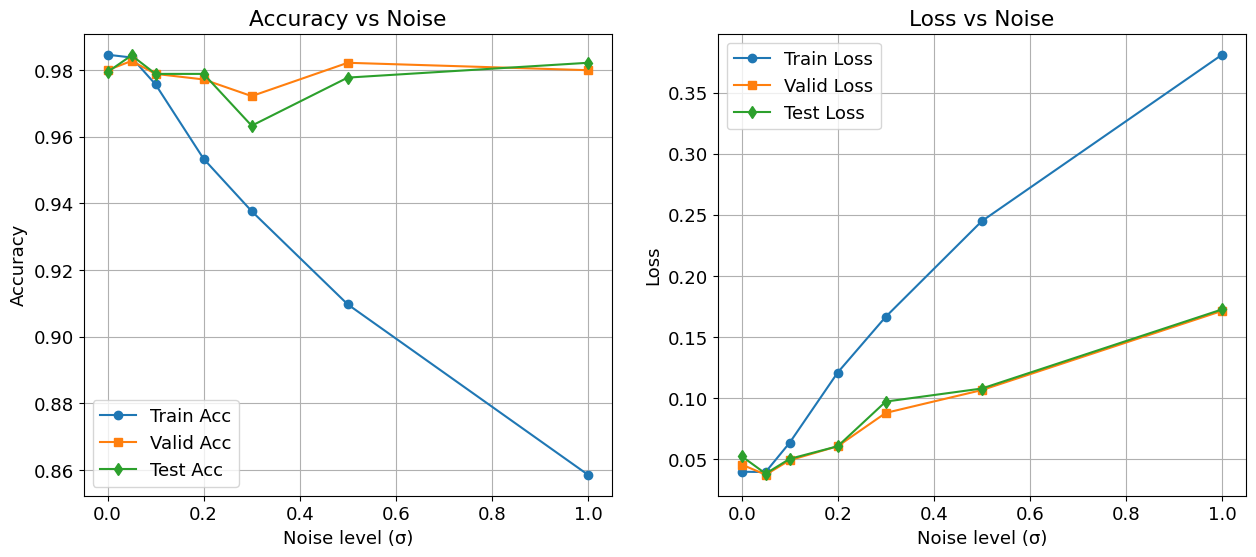

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow.random as tf_r


noise_levels = [0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

train_acc_final, train_loss_final = [], []
valid_acc_final, valid_loss_final = [], []
test_acc_V, test_loss_V = [], []

N = len(x)
N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test  = int(perc_test * N)

x_train_raw, y_train_raw = x[0:N_train], y[0:N_train]
x_valid_raw, y_valid = x[N_train : N_train+N_valid], y[N_train : N_train+N_valid]
x_test_raw,  y_test  = x[N_train+N_valid : N_train+N_valid+N_test], y[N_train+N_valid : N_train+N_valid+N_test]




#introducing noise
for noise in noise_levels:
    
    x_train_noisy = np.vstack((x_train_raw,x_train_raw + np.random.normal(0, noise, size=x_train_raw.shape)))
    y_train_augmented = np.concatenate((y_train_raw, y_train_raw))
    
    mu = np.mean(x_train_noisy, axis=0)
    sig = np.std(x_train_noisy, axis=0)
    
    x_train = Standardize(x_train_noisy, mu, sig)
    x_valid = Standardize(x_valid_raw, mu, sig)
    x_test  = Standardize(x_test_raw, mu, sig)

    
#NN wiht best parameters
    tf_r.set_seed(12345)
    model = Sequential([
        Dense(L, input_shape=(L,), activation='relu'),
        Dense(20, activation=best_act),
        Dropout(best_drop),
        Dense(20, activation=best_act),
        Dropout(best_drop),
        Dense(20, activation=best_act),
        Dropout(best_drop),
        Dense(1, activation='sigmoid')
    ])

    if best_opt == "adam":
        opt = Adam(learning_rate=best_lr) 
    elif best_opt == "rmsprop":
        opt = RMSprop(learning_rate=best_lr, rho=0.9)

    elif best_opt == "nesterov":
        opt = SGD(learning_rate=best_lr, momentum=0.9, nesterov=True)

    else:
        opt = "adam"
 
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    
    # Fit
    fit = model.fit(x_train, y_train_augmented, epochs=200, batch_size=50, shuffle=True,
                    validation_data=(x_valid, y_valid), verbose=0)

    if noise == noise_levels[0] or noise == noise_levels[-1]:
        fig_hist, AX = plt.subplots(1, 2, figsize=(10, 4))
    
        
        AX[1].plot(fit.history['loss'], label='Train Loss', color='blue', ls='--')
        AX[1].plot(fit.history['val_loss'], label='Valid Loss', color='red')
        AX[1].set_title('Loss vs Epochs')
        AX[1].set_xlabel('Epochs')
        AX[1].legend()
        AX[1].grid(True, linestyle='--', alpha=0.6)
    
        
        AX[0].plot(fit.history['accuracy'], label='Train Acc', color='blue', ls='--')
        AX[0].plot(fit.history['val_accuracy'], label='Valid Acc', color='red')
        AX[0].set_title('Accuracy vs Epochs')
        AX[0].set_xlabel('Epochs')
        AX[0].legend()
        AX[0].grid(True, linestyle='--', alpha=0.6)
        
        
        plt.show()
    
    
    #Boundary plot
        dX = 0.1
        X1 = np.arange(0, 10 + dX, dX)
        LG = len(X1)
        X_m, Y_m = np.meshgrid(X1, X1)
        grid = np.random.rand(LG**2, L) * B
        grid[:, :2] = np.reshape(np.array((X_m, Y_m)).T, (LG**2, 2))
        grid_r = Standardize(grid, mu, sig)
        pred = model.predict(grid_r, verbose=0).reshape((LG, LG))
    
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].scatter(x_train_noisy[:,0], x_train_noisy[:,1], c=y_train_augmented, s=5, alpha=0.5)
        ax[0].set_title(f"Train Data (Noise {noise})")
        ax[1].pcolormesh(X1, X1, pred, shading='auto')
        ax[1].set_title(f"Boundary (Noise {noise})")
        plt.show()

    train_acc_final.append(fit.history['accuracy'][-1])
    train_loss_final.append(fit.history['loss'][-1])
    valid_acc_final.append(fit.history['val_accuracy'][-1])
    valid_loss_final.append(fit.history['val_loss'][-1])
        
    l, a = model.evaluate(x_test, y_test, verbose=0)
    test_loss_V.append(l)
    test_acc_V.append(a)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(noise_levels, train_acc_final, 'o-', label='Train Acc')
ax1.plot(noise_levels, valid_acc_final, 's-', label='Valid Acc')
ax1.plot(noise_levels, test_acc_V, 'd-', label='Test Acc')
ax1.set_xlabel('Noise level (σ)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Noise')
ax1.legend(); ax1.grid(True)

ax2.plot(noise_levels, train_loss_final, 'o-', label='Train Loss')
ax2.plot(noise_levels, valid_loss_final, 's-', label='Valid Loss')
ax2.plot(noise_levels, test_loss_V, 'd-', label='Test Loss')
ax2.set_xlabel('Noise level (σ)')
ax2.set_ylabel('Loss')
ax2.set_title('Loss vs Noise')
ax2.legend(); ax2.grid(True)

plt.show()

#### Train accuracy decrese with the increasing of noise, but validation and test are stable